In [ ]:
# ============================================================
# 7 : ADVANCED PIPELINE — GOLD NEXT-DAY RETURN PREDICTION
# ============================================================
# Pipeline:
#   Step 1 : Hyperparameter Tuning (Optuna + TimeSeriesSplit)
#   Step 2 : Ensemble (LightGBM + XGBoost + CatBoost)
#   Step 3 : Regime-Switching Model
#   Step 4 : Walk-Forward Validation
#   Step 5 : Classification Head (direction signal)
# ============================================================

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, roc_auc_score
)
from sklearn.model_selection import TimeSeriesSplit

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style (ต่อเนื่องจาก notebook ก่อน)
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"
plt.style.use("dark_background")

# ============================================================
# 0 : LOAD SPLITS  (เหมือนเดิม)
# ============================================================
print("=" * 60)
print("0 : LOAD SPLITS")
print("=" * 60)

BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# รวม train+val สำหรับ Optuna / Walk-Forward
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"  X_train    : {X_train.shape}")
print(f"  X_val      : {X_val.shape}")
print(f"  X_test     : {X_test.shape}")
print(f"  X_trainval : {X_trainval.shape}")


# ============================================================
# HELPER — METRICS
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    print(f"  [{name}] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  DirAcc={dir_acc:.1f}%")
    return {"rmse": rmse, "mae": mae, "r2": r2, "dir_acc": dir_acc}


# ============================================================
# STEP 1 : HYPERPARAMETER TUNING (OPTUNA + TimeSeriesSplit)
# ============================================================
print("\n" + "=" * 60)
print("STEP 1 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit")
print("=" * 60)

# ── ใช้ TimeSeriesSplit บน train+val เพื่อ avoid leakage
N_SPLITS   = 5       # จำนวน fold
N_TRIALS   = 50      # จำนวน Optuna trials (เพิ่มเป็น 100+ สำหรับ production)

tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)


def lgb_objective(trial):
    """Optuna objective สำหรับ LightGBM"""
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 127),
        "max_depth"        : trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }

    cv_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_trainval)):
        X_f_train, X_f_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_f_train, y_f_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_f_train, y_f_train,
            eval_set=[(X_f_val, y_f_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
        )
        pred  = model.predict(X_f_val)
        rmse  = np.sqrt(mean_squared_error(y_f_val, pred))
        cv_scores.append(rmse)

    return np.mean(cv_scores)


def xgb_objective(trial):
    """Optuna objective สำหรับ XGBoost"""
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 5),
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "tree_method"     : "hist",
        "verbosity"       : 0,
    }

    cv_scores = []
    for train_idx, val_idx in tscv.split(X_trainval):
        X_f_train, X_f_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_f_train, y_f_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_f_train, y_f_train,
            eval_set=[(X_f_val, y_f_val)],
            verbose=False,
        )
        pred = model.predict(X_f_val)
        rmse = np.sqrt(mean_squared_error(y_f_val, pred))
        cv_scores.append(rmse)

    return np.mean(cv_scores)


# ── Run Optuna ── LightGBM
print(f"\n  [Optuna] LightGBM — {N_TRIALS} trials ...")
study_lgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
print(f"  LightGBM best CV RMSE : {study_lgb.best_value:.4f}")
print(f"    Best params : {best_lgb_params}")


# ── Run Optuna ── XGBoost
print(f"\n  [Optuna] XGBoost — {N_TRIALS} trials ...")
study_xgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1,
                         "tree_method": "hist", "verbosity": 0})
print(f"  ✔ XGBoost best CV RMSE : {study_xgb.best_value:.4f}")
print(f"    Best params : {best_xgb_params}")


# ── Retrain ด้วย best params บน train → evaluate บน val+test
print("\n  Retraining with best hyperparameters ...")

tuned_lgb = lgb.LGBMRegressor(**best_lgb_params)
tuned_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

tuned_xgb = xgb.XGBRegressor(**best_xgb_params)
tuned_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print("\n  --- Tuned LightGBM ---")
m_lgb_val  = evaluate("Val ", y_val,  tuned_lgb.predict(X_val))
m_lgb_test = evaluate("Test", y_test, tuned_lgb.predict(X_test))

print("\n  --- Tuned XGBoost ---")
m_xgb_val  = evaluate("Val ", y_val,  tuned_xgb.predict(X_val))
m_xgb_test = evaluate("Test", y_test, tuned_xgb.predict(X_test))


# ============================================================
# STEP 2 : ENSEMBLE (LightGBM + XGBoost + CatBoost)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2 : ENSEMBLE — LightGBM + XGBoost + CatBoost")
print("=" * 60)

# ── Train CatBoost (ไม่ต้องการ Optuna แยก เพราะ CatBoost tune ตัวเองได้ดี)
print("\n  Training CatBoost ...")
cat_params = {
    "iterations"        : 1000,
    "learning_rate"     : 0.03,
    "depth"             : 6,
    "l2_leaf_reg"       : 3.0,
    "min_data_in_leaf"  : 20,
    "subsample"         : 0.8,
    "random_seed"       : RANDOM_STATE,
    "verbose"           : 0,
    "early_stopping_rounds": 50,
    "eval_metric"       : "RMSE",
    "task_type"         : "CPU",
}

tuned_cat = CatBoostRegressor(**cat_params)
tuned_cat.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False,
)

print("\n  --- CatBoost ---")
m_cat_val  = evaluate("Val ", y_val,  tuned_cat.predict(X_val))
m_cat_test = evaluate("Test", y_test, tuned_cat.predict(X_test))


# ── Weighted Ensemble
# น้ำหนักจาก val RMSE (inverse weight — ยิ่ง RMSE ต่ำ weight สูง)
def rmse_weights(*rmse_values):
    """คำนวณ inverse-RMSE weights"""
    inv = [1.0 / r for r in rmse_values]
    total = sum(inv)
    return [w / total for w in inv]

val_rmse_list = [m_lgb_val["rmse"], m_xgb_val["rmse"], m_cat_val["rmse"]]
w_lgb, w_xgb, w_cat = rmse_weights(*val_rmse_list)

print(f"\n  Ensemble weights (inverse RMSE on Val):")
print(f"    LightGBM : {w_lgb:.3f}")
print(f"    XGBoost  : {w_xgb:.3f}")
print(f"    CatBoost : {w_cat:.3f}")

# ── Val predictions
pred_lgb_val = tuned_lgb.predict(X_val)
pred_xgb_val = tuned_xgb.predict(X_val)
pred_cat_val = tuned_cat.predict(X_val)
pred_ens_val = w_lgb * pred_lgb_val + w_xgb * pred_xgb_val + w_cat * pred_cat_val

# ── Test predictions
pred_lgb_test = tuned_lgb.predict(X_test)
pred_xgb_test = tuned_xgb.predict(X_test)
pred_cat_test = tuned_cat.predict(X_test)
pred_ens_test = w_lgb * pred_lgb_test + w_xgb * pred_xgb_test + w_cat * pred_cat_test

print("\n  --- Weighted Ensemble ---")
m_ens_val  = evaluate("Val ", y_val,  pred_ens_val)
m_ens_test = evaluate("Test", y_test, pred_ens_test)


# ── Comparison table
comp_ensemble = pd.DataFrame({
    "Model"       : ["LightGBM (tuned)", "XGBoost (tuned)", "CatBoost", "Ensemble"],
    "Val RMSE"    : [m_lgb_val["rmse"], m_xgb_val["rmse"], m_cat_val["rmse"], m_ens_val["rmse"]],
    "Val DirAcc%" : [m_lgb_val["dir_acc"], m_xgb_val["dir_acc"], m_cat_val["dir_acc"], m_ens_val["dir_acc"]],
    "Test RMSE"   : [m_lgb_test["rmse"], m_xgb_test["rmse"], m_cat_test["rmse"], m_ens_test["rmse"]],
    "Test DirAcc%": [m_lgb_test["dir_acc"], m_xgb_test["dir_acc"], m_cat_test["dir_acc"], m_ens_test["dir_acc"]],
    "Test R²"     : [m_lgb_test["r2"], m_xgb_test["r2"], m_cat_test["r2"], m_ens_test["r2"]],
})
print("\n  Ensemble Comparison:")
print(comp_ensemble.to_string(index=False))


# ============================================================
# STEP 3 : REGIME-SWITCHING MODEL
# ============================================================
print("\n" + "=" * 60)
print("STEP 3 : REGIME-SWITCHING MODEL")
print("=" * 60)

# ── กำหนด regime บน train set (เหมือน notebook ก่อน)
rolling_vol  = y_train.rolling(60).std()
vol_median   = rolling_vol.median()
vol_thresh   = vol_median  # ใช้ median เป็น threshold

# ── สร้าง regime label function (ใช้ซ้ำสำหรับ val/test)
def get_regime(y_series: pd.Series, window: int = 60, threshold: float = None):
    """
    คืน Series ของ regime label: 'high' หรือ 'low'
    ถ้าไม่ระบุ threshold จะใช้ median ของ rolling std
    """
    vol = y_series.rolling(window).std()
    if threshold is None:
        threshold = vol.median()
    return (vol > threshold).map({True: "high", False: "low"}).fillna("low")

regime_train = get_regime(y_train, threshold=vol_thresh)
regime_val   = get_regime(pd.concat([y_train, y_val]), threshold=vol_thresh).loc[y_val.index]
regime_test  = get_regime(pd.concat([y_train, y_val, y_test]), threshold=vol_thresh).loc[y_test.index]

print(f"\n  Train regime distribution:\n{regime_train.value_counts().to_string()}")
print(f"\n  Val  regime distribution:\n{regime_val.value_counts().to_string()}")
print(f"\n  Test regime distribution:\n{regime_test.value_counts().to_string()}")

# ── Train แยกโมเดลต่อ regime
regime_params = dict(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

print("\n  Training regime-specific models ...")

# High volatility model
mask_high_train = (regime_train == "high")
model_regime_high = lgb.LGBMRegressor(**regime_params)
model_regime_high.fit(X_train[mask_high_train], y_train[mask_high_train])
print(f"  ✔ High-vol model trained on {mask_high_train.sum()} rows")

# Low volatility model
mask_low_train = (regime_train == "low")
model_regime_low = lgb.LGBMRegressor(**regime_params)
model_regime_low.fit(X_train[mask_low_train], y_train[mask_low_train])
print(f"  ✔ Low-vol model trained on {mask_low_train.sum()} rows")

# ── Predict: เลือกโมเดลตาม regime ของแต่ละ row
def regime_predict(X: pd.DataFrame, regime_series: pd.Series,
                   model_high, model_low) -> np.ndarray:
    """Blend predictions: high-vol → model_high, low-vol → model_low"""
    pred = np.zeros(len(X))
    mask_h = (regime_series == "high").values
    mask_l = ~mask_h
    if mask_h.any():
        pred[mask_h] = model_high.predict(X.iloc[mask_h])
    if mask_l.any():
        pred[mask_l] = model_low.predict(X.iloc[mask_l])
    return pred

pred_regime_val  = regime_predict(X_val,  regime_val,  model_regime_high, model_regime_low)
pred_regime_test = regime_predict(X_test, regime_test, model_regime_high, model_regime_low)

print("\n  --- Regime-Switching Model ---")
m_regime_val  = evaluate("Val ", y_val,  pred_regime_val)
m_regime_test = evaluate("Test", y_test, pred_regime_test)


# ── Soft blend: ผสม regime model กับ ensemble (50/50 เริ่มต้น)
REGIME_BLEND_WEIGHT = 0.4   # สัดส่วนของ regime model (ปรับได้)
ENS_BLEND_WEIGHT    = 1.0 - REGIME_BLEND_WEIGHT

pred_blended_val  = REGIME_BLEND_WEIGHT * pred_regime_val  + ENS_BLEND_WEIGHT * pred_ens_val
pred_blended_test = REGIME_BLEND_WEIGHT * pred_regime_test + ENS_BLEND_WEIGHT * pred_ens_test

print(f"\n  --- Blended (Ensemble {ENS_BLEND_WEIGHT:.0%} + Regime {REGIME_BLEND_WEIGHT:.0%}) ---")
m_blend_val  = evaluate("Val ", y_val,  pred_blended_val)
m_blend_test = evaluate("Test", y_test, pred_blended_test)

# ── เลือก best final prediction
candidates = {
    "Ensemble"      : (m_ens_test["rmse"],    pred_ens_val,     pred_ens_test),
    "Regime-Switch" : (m_regime_test["rmse"], pred_regime_val,  pred_regime_test),
    "Blended"       : (m_blend_test["rmse"],  pred_blended_val, pred_blended_test),
}
best_name, (_, best_pred_val_final, best_pred_test_final) = min(
    candidates.items(), key=lambda kv: kv[1][0]
)
print(f"\n  Best final model: {best_name}")


# ============================================================
# STEP 4 : WALK-FORWARD VALIDATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 4 : WALK-FORWARD VALIDATION")
print("=" * 60)

# ── Walk-forward: ขยาย train window ทีละ step, predict 1 chunk
WF_INIT_TRAIN_ROWS = len(X_train)  # เริ่มด้วย train set เดิม
WF_STEP            = 63            # predict ทีละ ~1 quarter (63 trading days)
WF_RETRAIN_EVERY   = 63           # retrain ทุก step

X_wf = pd.concat([X_train, X_val, X_test])
y_wf = pd.concat([y_train, y_val, y_test])

wf_params = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

wf_predictions = []
wf_actuals     = []
wf_dates       = []
wf_fold_metrics = []

start_test = WF_INIT_TRAIN_ROWS
n_total    = len(X_wf)
fold       = 0

print(f"\n  Walk-forward config:")
print(f"    Initial train size : {WF_INIT_TRAIN_ROWS} rows")
print(f"    Step size          : {WF_STEP} rows")
print(f"    Total rows         : {n_total}")

while start_test < n_total:
    end_test = min(start_test + WF_STEP, n_total)

    X_wf_train = X_wf.iloc[:start_test]
    y_wf_train = y_wf.iloc[:start_test]
    X_wf_chunk = X_wf.iloc[start_test:end_test]
    y_wf_chunk = y_wf.iloc[start_test:end_test]

    # Retrain ทุก fold
    wf_model = lgb.LGBMRegressor(**wf_params)
    wf_model.fit(X_wf_train, y_wf_train)

    chunk_pred = wf_model.predict(X_wf_chunk)
    chunk_rmse = np.sqrt(mean_squared_error(y_wf_chunk, chunk_pred))
    chunk_dir  = np.mean(np.sign(y_wf_chunk) == np.sign(chunk_pred)) * 100

    wf_predictions.extend(chunk_pred.tolist())
    wf_actuals.extend(y_wf_chunk.tolist())
    wf_dates.extend(y_wf_chunk.index.tolist())
    wf_fold_metrics.append({
        "fold"     : fold,
        "start"    : y_wf_chunk.index[0].date(),
        "end"      : y_wf_chunk.index[-1].date(),
        "n_rows"   : len(y_wf_chunk),
        "RMSE"     : chunk_rmse,
        "DirAcc%"  : chunk_dir,
    })

    fold += 1
    start_test = end_test

wf_df = pd.DataFrame({
    "date"      : wf_dates,
    "actual"    : wf_actuals,
    "predicted" : wf_predictions,
}).set_index("date")

wf_overall_rmse = np.sqrt(mean_squared_error(wf_df["actual"], wf_df["predicted"]))
wf_overall_dir  = np.mean(np.sign(wf_df["actual"]) == np.sign(wf_df["predicted"])) * 100
wf_overall_r2   = r2_score(wf_df["actual"], wf_df["predicted"])

print(f"\n  Walk-forward fold results:")
fold_df = pd.DataFrame(wf_fold_metrics)
print(fold_df.to_string(index=False))

print(f"\n  Walk-Forward Overall:")
print(f"    RMSE    = {wf_overall_rmse:.4f}")
print(f"    DirAcc  = {wf_overall_dir:.1f}%")
print(f"    R²      = {wf_overall_r2:.4f}")


# ============================================================
# STEP 5 : CLASSIFICATION HEAD (Direction Signal)
# ============================================================
print("\n" + "=" * 60)
print("STEP 5 : CLASSIFICATION HEAD — Direction Signal")
print("=" * 60)

# ── สร้าง binary target: 1 = ราคาขึ้น (return > 0), 0 = ราคาลง
y_train_cls = (y_train > 0).astype(int)
y_val_cls   = (y_val   > 0).astype(int)
y_test_cls  = (y_test  > 0).astype(int)

print(f"\n  Class distribution (Train): UP={y_train_cls.mean():.1%}  DOWN={(1-y_train_cls.mean()):.1%}")

# ── Feature engineering: เพิ่ม regression predictions เป็น feature
# train อยู่แล้วบน train set → ใช้ out-of-fold pred ของ LGBMRegressor
print("\n  Generating OOF regression predictions for classification features ...")

oof_pred_train = np.zeros(len(X_train))
oof_tscv = TimeSeriesSplit(n_splits=5, gap=1)

for tr_idx, vl_idx in oof_tscv.split(X_train):
    _model = lgb.LGBMRegressor(**wf_params)
    _model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_pred_train[vl_idx] = _model.predict(X_train.iloc[vl_idx])

# ── Augment features with regression signal
def add_reg_signal(X: pd.DataFrame, reg_pred: np.ndarray) -> pd.DataFrame:
    X2 = X.copy()
    X2["f_reg_pred"]       = reg_pred
    X2["f_reg_pred_sign"]  = np.sign(reg_pred)
    X2["f_reg_pred_abs"]   = np.abs(reg_pred)
    return X2

X_train_cls = add_reg_signal(X_train, oof_pred_train)
X_val_cls   = add_reg_signal(X_val,   tuned_lgb.predict(X_val))
X_test_cls  = add_reg_signal(X_test,  tuned_lgb.predict(X_test))

# ── Train LightGBM Classifier
cls_params = dict(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    objective="binary", metric="binary_logloss",
    class_weight="balanced",
)

cls_model = lgb.LGBMClassifier(**cls_params)
cls_model.fit(
    X_train_cls, y_train_cls,
    eval_set=[(X_val_cls, y_val_cls)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

# ── Evaluate
pred_cls_val_proba  = cls_model.predict_proba(X_val_cls)[:, 1]
pred_cls_test_proba = cls_model.predict_proba(X_test_cls)[:, 1]
pred_cls_val        = (pred_cls_val_proba  > 0.5).astype(int)
pred_cls_test       = (pred_cls_test_proba > 0.5).astype(int)

val_acc   = accuracy_score(y_val_cls, pred_cls_val)
test_acc  = accuracy_score(y_test_cls, pred_cls_test)
val_auc   = roc_auc_score(y_val_cls, pred_cls_val_proba)
test_auc  = roc_auc_score(y_test_cls, pred_cls_test_proba)

print(f"\n  --- LightGBM Classifier (Direction) ---")
print(f"  [Val ] Accuracy={val_acc:.4f}  AUC={val_auc:.4f}")
print(f"  [Test] Accuracy={test_acc:.4f}  AUC={test_auc:.4f}")
print(f"\n  Test Classification Report:")
print(classification_report(y_test_cls, pred_cls_test, target_names=["DOWN", "UP"]))

# ── Train CatBoost Classifier
print("\n  Training CatBoost Classifier ...")
cat_cls_params = {
    "iterations"           : 800,
    "learning_rate"        : 0.03,
    "depth"                : 6,
    "l2_leaf_reg"          : 3.0,
    "subsample"            : 0.8,
    "random_seed"          : RANDOM_STATE,
    "verbose"              : 0,
    "early_stopping_rounds": 50,
    "eval_metric"          : "AUC",
    "auto_class_weights"   : "Balanced",
    "task_type"            : "CPU",
}

cat_cls_model = CatBoostClassifier(**cat_cls_params)
cat_cls_model.fit(
    X_train_cls, y_train_cls,
    eval_set=(X_val_cls, y_val_cls),
    verbose=False,
)

pred_cat_cls_val_proba  = cat_cls_model.predict_proba(X_val_cls)[:, 1]
pred_cat_cls_test_proba = cat_cls_model.predict_proba(X_test_cls)[:, 1]

cat_val_auc  = roc_auc_score(y_val_cls, pred_cat_cls_val_proba)
cat_test_auc = roc_auc_score(y_test_cls, pred_cat_cls_test_proba)
cat_test_acc = accuracy_score(y_test_cls, (pred_cat_cls_test_proba > 0.5).astype(int))

print(f"  [Val ] AUC={cat_val_auc:.4f}")
print(f"  [Test] Accuracy={cat_test_acc:.4f}  AUC={cat_test_auc:.4f}")

# ── Ensemble Classification Probabilities (avg of LGB + CatBoost)
pred_cls_ens_proba_val  = 0.5 * pred_cls_val_proba  + 0.5 * pred_cat_cls_val_proba
pred_cls_ens_proba_test = 0.5 * pred_cls_test_proba + 0.5 * pred_cat_cls_test_proba

ens_val_auc  = roc_auc_score(y_val_cls, pred_cls_ens_proba_val)
ens_test_auc = roc_auc_score(y_test_cls, pred_cls_ens_proba_test)
ens_test_acc = accuracy_score(y_test_cls, (pred_cls_ens_proba_test > 0.5).astype(int))

print(f"\n  --- Ensemble Classifier (LGB + CatBoost avg) ---")
print(f"  [Val ] AUC={ens_val_auc:.4f}")
print(f"  [Test] Accuracy={ens_test_acc:.4f}  AUC={ens_test_auc:.4f}")


0 : LOAD SPLITS
  X_train    : (1478, 69)
  X_val      : (501, 69)
  X_test     : (563, 69)
  X_trainval : (1979, 69)

STEP 1 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit

  [Optuna] LightGBM — 50 trials ...
  ✔ LightGBM best CV RMSE : 0.7090
    Best params : {'n_estimators': 750, 'learning_rate': 0.06929297547288632, 'num_leaves': 74, 'max_depth': 7, 'min_child_samples': 89, 'subsample': 0.8207793052812722, 'colsample_bytree': 0.6518133631177891, 'reg_alpha': 0.003879201207054904, 'reg_lambda': 1.7691305543672913, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

  [Optuna] XGBoost — 50 trials ...
  ✔ XGBoost best CV RMSE : 0.7128
    Best params : {'n_estimators': 1269, 'learning_rate': 0.010221195527595985, 'max_depth': 3, 'min_child_weight': 4, 'subsample': 0.868305441704238, 'colsample_bytree': 0.4267934698615522, 'reg_alpha': 5.208957474091339, 'reg_lambda': 0.9759645270747916, 'gamma': 3.8173282783296583, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity


STEP 6 : VISUALIZATION
  ✔ Saved visualization → 7_advanced_pipeline.png


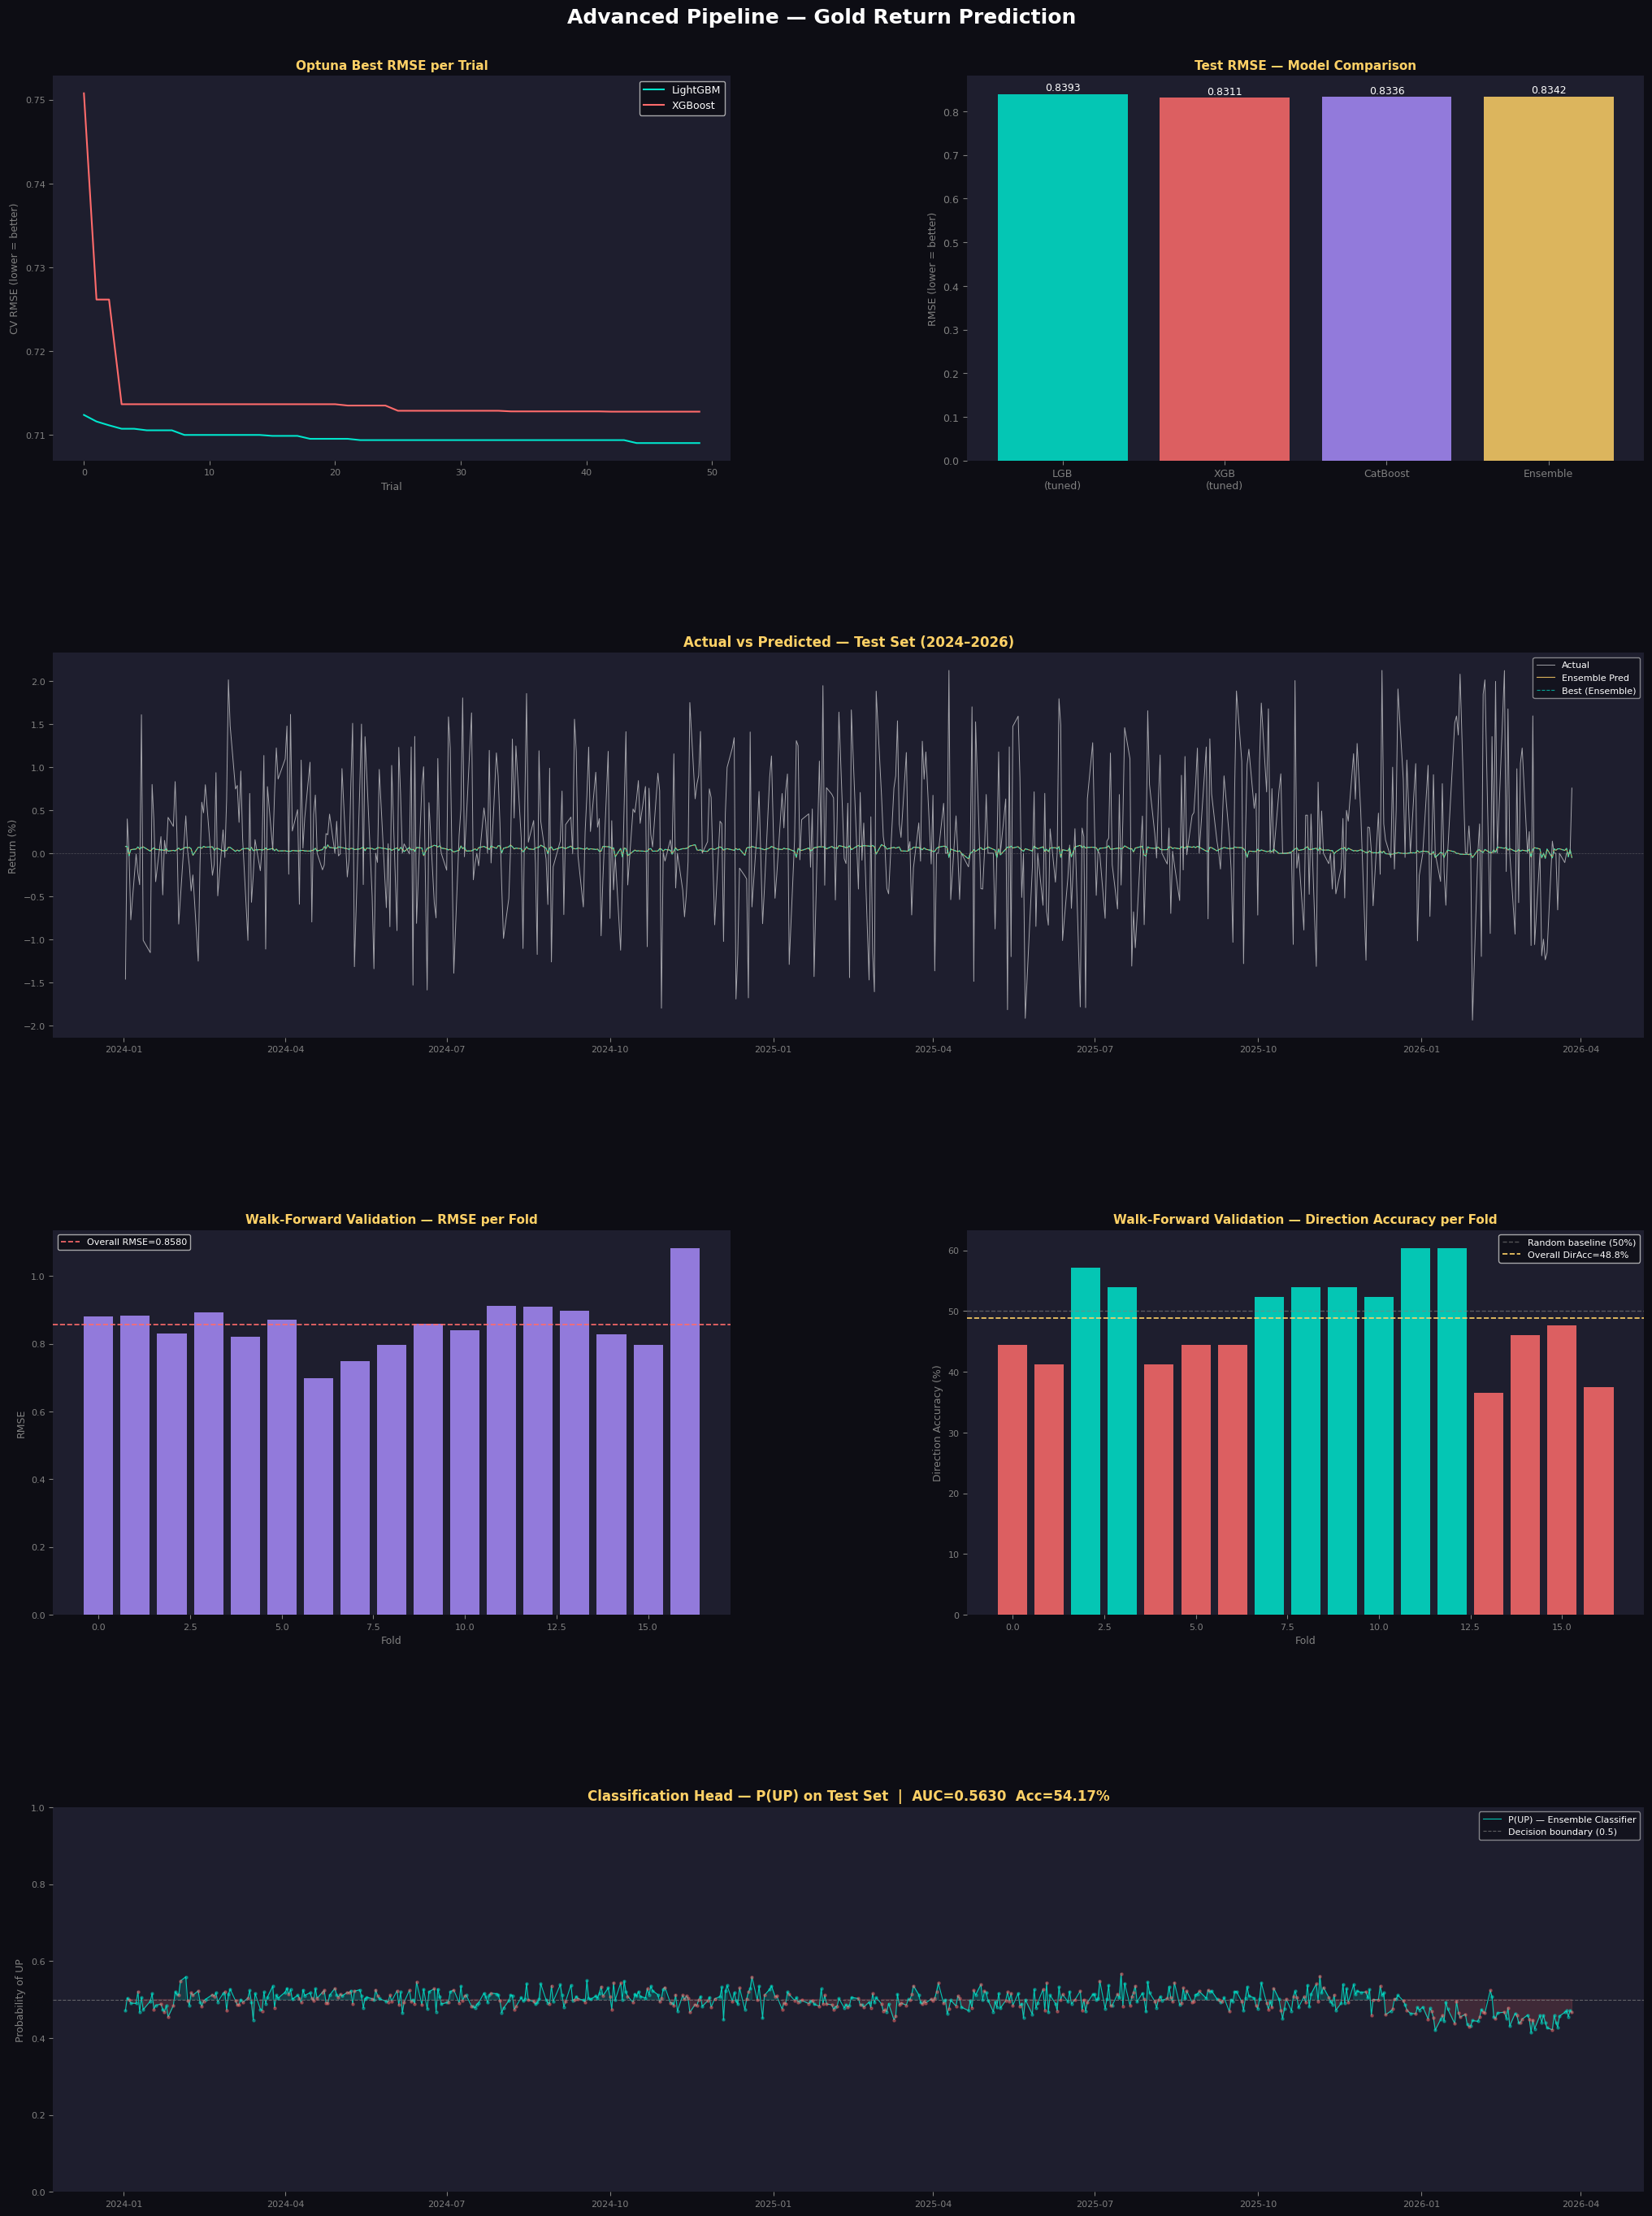

In [3]:
# ============================================================
# STEP 6 : VISUALIZATION — รวมทุก Step
# ============================================================
print("\n" + "=" * 60)
print("STEP 6 : VISUALIZATION")
print("=" * 60)

fig = plt.figure(figsize=(22, 28), facecolor=FIG_COLOR)
fig.suptitle("Advanced Pipeline — Gold Return Prediction", fontsize=18,
             color="white", fontweight="bold", y=0.99)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35,
                       left=0.07, right=0.96, top=0.96, bottom=0.03)

# ── Panel 1: Optuna History (LGB vs XGB)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(GRID_COLOR)
lgb_values = [t.value for t in study_lgb.trials]
xgb_values = [t.value for t in study_xgb.trials]
ax1.plot(np.minimum.accumulate(lgb_values), color=ACCENT1, lw=1.5, label="LightGBM")
ax1.plot(np.minimum.accumulate(xgb_values), color=ACCENT2, lw=1.5, label="XGBoost")
ax1.set_title("Optuna Best RMSE per Trial", color=ACCENT3, fontsize=11, fontweight="bold")
ax1.set_xlabel("Trial", color="gray", fontsize=9)
ax1.set_ylabel("CV RMSE (lower = better)", color="gray", fontsize=9)
ax1.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax1.tick_params(colors="gray", labelsize=8)
ax1.spines[:].set_visible(False)

# ── Panel 2: Ensemble Comparison Bar
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(GRID_COLOR)
model_names = ["LGB\n(tuned)", "XGB\n(tuned)", "CatBoost", "Ensemble"]
test_rmses  = [m_lgb_test["rmse"], m_xgb_test["rmse"], m_cat_test["rmse"], m_ens_test["rmse"]]
colors_bar  = [ACCENT1, ACCENT2, ACCENT4, ACCENT3]
bars = ax2.bar(model_names, test_rmses, color=colors_bar, alpha=0.85, edgecolor="none")
for bar, val in zip(bars, test_rmses):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}",
             ha="center", va="bottom", color="white", fontsize=9)
ax2.set_title("Test RMSE — Model Comparison", color=ACCENT3, fontsize=11, fontweight="bold")
ax2.set_ylabel("RMSE (lower = better)", color="gray", fontsize=9)
ax2.tick_params(colors="gray", labelsize=9)
ax2.spines[:].set_visible(False)

# ── Panel 3: Ensemble Actual vs Predicted (Test)
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(GRID_COLOR)
ax3.plot(X_test.index, y_test.values, color="white", lw=0.7, alpha=0.6, label="Actual")
ax3.plot(X_test.index, pred_ens_test,  color=ACCENT3, lw=0.8, alpha=0.85, label="Ensemble Pred")
ax3.plot(X_test.index, best_pred_test_final, color=ACCENT1, lw=0.8, alpha=0.7, linestyle="--",
         label=f"Best ({best_name})")
ax3.axhline(0, color="gray", linestyle="--", lw=0.5, alpha=0.5)
ax3.set_title("Actual vs Predicted — Test Set (2024–2026)", color=ACCENT3, fontsize=12, fontweight="bold")
ax3.set_ylabel("Return (%)", color="gray", fontsize=9)
ax3.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.6)
ax3.tick_params(colors="gray", labelsize=8)
ax3.spines[:].set_visible(False)
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# ── Panel 4: Walk-Forward — fold RMSE
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(GRID_COLOR)
ax4.bar(range(len(wf_fold_metrics)),
        [f["RMSE"] for f in wf_fold_metrics],
        color=ACCENT4, alpha=0.85, edgecolor="none")
ax4.axhline(wf_overall_rmse, color=ACCENT2, linestyle="--", lw=1.2,
            label=f"Overall RMSE={wf_overall_rmse:.4f}")
ax4.set_title("Walk-Forward Validation — RMSE per Fold", color=ACCENT3, fontsize=11, fontweight="bold")
ax4.set_xlabel("Fold", color="gray", fontsize=9)
ax4.set_ylabel("RMSE", color="gray", fontsize=9)
ax4.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax4.tick_params(colors="gray", labelsize=8)
ax4.spines[:].set_visible(False)

# ── Panel 5: Walk-Forward — DirAcc per fold
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(GRID_COLOR)
dir_accs = [f["DirAcc%"] for f in wf_fold_metrics]
colors_wf = [ACCENT1 if d > 50 else ACCENT2 for d in dir_accs]
ax5.bar(range(len(wf_fold_metrics)), dir_accs, color=colors_wf, alpha=0.85, edgecolor="none")
ax5.axhline(50, color="gray", linestyle="--", lw=1.0, alpha=0.6, label="Random baseline (50%)")
ax5.axhline(wf_overall_dir, color=ACCENT3, linestyle="--", lw=1.2,
            label=f"Overall DirAcc={wf_overall_dir:.1f}%")
ax5.set_title("Walk-Forward Validation — Direction Accuracy per Fold", color=ACCENT3,
              fontsize=11, fontweight="bold")
ax5.set_xlabel("Fold", color="gray", fontsize=9)
ax5.set_ylabel("Direction Accuracy (%)", color="gray", fontsize=9)
ax5.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax5.tick_params(colors="gray", labelsize=8)
ax5.spines[:].set_visible(False)

# ── Panel 6: Classification — Probability over Test Period
ax6 = fig.add_subplot(gs[3, :])
ax6.set_facecolor(GRID_COLOR)
ax6.plot(X_test.index, pred_cls_ens_proba_test, color=ACCENT1, lw=0.8, alpha=0.85,
         label="P(UP) — Ensemble Classifier")
ax6.fill_between(X_test.index, pred_cls_ens_proba_test, 0.5,
                 where=(pred_cls_ens_proba_test > 0.5), color=ACCENT1, alpha=0.15)
ax6.fill_between(X_test.index, pred_cls_ens_proba_test, 0.5,
                 where=(pred_cls_ens_proba_test < 0.5), color=ACCENT2, alpha=0.15)
ax6.axhline(0.5, color="gray", linestyle="--", lw=0.8, alpha=0.7, label="Decision boundary (0.5)")
# mark actual direction
correct_mask = (y_test_cls.values == (pred_cls_ens_proba_test > 0.5).astype(int))
ax6.scatter(X_test.index[correct_mask],
            pred_cls_ens_proba_test[correct_mask],
            color=ACCENT1, s=5, alpha=0.4, zorder=3)
ax6.scatter(X_test.index[~correct_mask],
            pred_cls_ens_proba_test[~correct_mask],
            color=ACCENT2, s=5, alpha=0.4, zorder=3)
ax6.set_title(f"Classification Head — P(UP) on Test Set  |  AUC={ens_test_auc:.4f}  Acc={ens_test_acc:.2%}",
              color=ACCENT3, fontsize=12, fontweight="bold")
ax6.set_ylabel("Probability of UP", color="gray", fontsize=9)
ax6.set_ylim(0, 1)
ax6.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.6)
ax6.tick_params(colors="gray", labelsize=8)
ax6.spines[:].set_visible(False)
ax6.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

plt.savefig(BASE + "7_advanced_pipeline.png", dpi=140, bbox_inches="tight", facecolor=FIG_COLOR)
print("  ✔ Saved visualization → 7_advanced_pipeline.png")
plt.show()


In [5]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"""
  ┌────────────────────────────────────────────────────────────┐
  │  STEP 1 — HYPERPARAMETER TUNING (Optuna, {N_TRIALS} trials)        │
  │    LightGBM best CV RMSE : {study_lgb.best_value:.4f}                    │
  │    XGBoost  best CV RMSE : {study_xgb.best_value:.4f}                    │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 2 — ENSEMBLE                                         │
  │    Test RMSE    : {m_ens_test['rmse']:.4f}                              │
  │    Test DirAcc  : {m_ens_test['dir_acc']:.1f}%                             │
  │    Test R²      : {m_ens_test['r2']:.4f}                              │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 3 — REGIME-SWITCHING MODEL                           │
  │    Best final   : {best_name:<30}       │
  │    Test RMSE    : {candidates[best_name][0]:.4f}                              │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 4 — WALK-FORWARD VALIDATION                          │
  │    Overall RMSE : {wf_overall_rmse:.4f}                              │
  │    Overall Dir  : {wf_overall_dir:.1f}%                             │
  │    Overall R²   : {wf_overall_r2:.4f}                              │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 5 — CLASSIFICATION HEAD                              │
  │    Test Accuracy: {ens_test_acc:.2%}                             │
  │    Test AUC     : {ens_test_auc:.4f}                              │
  └────────────────────────────────────────────────────────────┘
""")



FINAL SUMMARY

  ┌────────────────────────────────────────────────────────────┐
  │  STEP 1 — HYPERPARAMETER TUNING (Optuna, 50 trials)        │
  │    LightGBM best CV RMSE : 0.7090                    │
  │    XGBoost  best CV RMSE : 0.7128                    │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 2 — ENSEMBLE                                         │
  │    Test RMSE    : 0.8342                              │
  │    Test DirAcc  : 53.6%                             │
  │    Test R²      : -0.0399                              │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 3 — REGIME-SWITCHING MODEL                           │
  │    Best final   : Ensemble                             │
  │    Test RMSE    : 0.8342                              │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 4 — WALK-FORWARD VALIDATION                          │
  │    Overall RMSE : 0.8580                  

In [ ]:
# =======================================================================
# SAVE REGRESSION PREDICTIONS FOR BACKTESTING
# =======================================================================
# วิธีใช้ : เพิ่ม block นี้ต่อท้าย notebook regression ของคุณ
#           หรือรันแยกหลังจาก train โมเดล regression เสร็จแล้ว
#
# สิ่งที่ต้องมีก่อนรัน:
#   - reg_model    : trained regression model (fitted แล้ว)
#   - X_train, X_val, X_test : feature DataFrames (Date index)
#   - y_train_reg, y_val_reg, y_test_reg : target (% return หรือ log return)
#   - scaler (optional) : ถ้าใช้ scaled target ต้อง inverse_transform ก่อน
# =======================================================================

import pandas as pd
import numpy as np
import os

SAVE_DIR = "../../../data/processed/predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

# =======================================================================
# SECTION A : GENERATE PREDICTIONS
# =======================================================================
# ── predict บน train / val / test
# หมายเหตุ: ถ้า target เป็น scaled (ผ่าน StandardScaler / MinMaxScaler)
#            ให้ inverse_transform ก่อน แล้วค่อยใส่ใน DataFrame

y_train_pred_reg = reg_model.predict(X_train)
y_val_pred_reg   = reg_model.predict(X_val)
y_test_pred_reg  = reg_model.predict(X_test)

# ── ถ้าใช้ scaler บน y (uncomment ถ้าจำเป็น):
# y_train_pred_reg = scaler_y.inverse_transform(y_train_pred_reg.reshape(-1,1)).flatten()
# y_val_pred_reg   = scaler_y.inverse_transform(y_val_pred_reg.reshape(-1,1)).flatten()
# y_test_pred_reg  = scaler_y.inverse_transform(y_test_pred_reg.reshape(-1,1)).flatten()

# =======================================================================
# SECTION B : BUILD DATAFRAMES
# =======================================================================
def build_reg_pred_df(X, y_true, y_pred):
    """
    สร้าง DataFrame สำหรับ backtest
    y_true / y_pred ต้องเป็น % return หรือ log return
    ค่าบวก = คาดว่าราคาขึ้น, ค่าลบ = คาดว่าราคาลง
    """
    df = pd.DataFrame(index=X.index)
    df["actual_return"]   = np.array(y_true)     # actual return (ground truth)
    df["pred_return"]     = y_pred               # predicted return จากโมเดล

    # ── derive direction จาก predicted return
    # (เพื่อใช้ merge กับ clf predictions ทีหลัง)
    df["pred_direction_reg"] = np.sign(y_pred).astype(int)  # -1 / 0 / +1

    # ── magnitude: ยิ่ง |pred_return| สูง → โมเดลมั่นใจว่าเคลื่อนไหวมาก
    df["pred_magnitude"]  = np.abs(y_pred)

    # ── actual direction (ground truth จาก return)
    df["actual_direction_reg"] = np.sign(np.array(y_true)).astype(int)

    # ── directional correctness (1 = ทาย direction ถูก, 0 = ผิด)
    df["dir_correct"] = (df["pred_direction_reg"] == df["actual_direction_reg"]).astype(int)

    return df

train_reg_df = build_reg_pred_df(X_train, y_train_reg, y_train_pred_reg)
val_reg_df   = build_reg_pred_df(X_val,   y_val_reg,   y_val_pred_reg)
test_reg_df  = build_reg_pred_df(X_test,  y_test_reg,  y_test_pred_reg)
full_reg_df  = pd.concat([train_reg_df, val_reg_df, test_reg_df])
full_reg_df.index.name = "Date"

# =======================================================================
# SECTION C : QUICK SANITY CHECK
# =======================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 60)
print(" REGRESSION PREDICTION SANITY CHECK")
print("=" * 60)

for name, y_true, y_pred in [
    ("Train", train_reg_df["actual_return"], train_reg_df["pred_return"]),
    ("Val",   val_reg_df["actual_return"],   val_reg_df["pred_return"]),
    ("Test",  test_reg_df["actual_return"],  test_reg_df["pred_return"]),
]:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    dir_acc = (np.sign(y_true) == np.sign(y_pred)).mean()
    print(f"\n  [{name}]")
    print(f"    MAE          : {mae:.6f}")
    print(f"    RMSE         : {rmse:.6f}")
    print(f"    Correlation  : {corr:.4f}")
    print(f"    Dir Accuracy : {dir_acc:.4f}  (sign correct)")

# =======================================================================
# SECTION D : SAVE TO CSV
# =======================================================================
train_reg_df.to_csv(f"{SAVE_DIR}/reg_predictions_train.csv")
val_reg_df.to_csv(f"{SAVE_DIR}/reg_predictions_val.csv")
test_reg_df.to_csv(f"{SAVE_DIR}/reg_predictions_test.csv")
full_reg_df.to_csv(f"{SAVE_DIR}/reg_predictions_full.csv")

print(f"\n  ✔ Saved: reg_predictions_train.csv  ({len(train_reg_df):,} rows)")
print(f"  ✔ Saved: reg_predictions_val.csv    ({len(val_reg_df):,} rows)")
print(f"  ✔ Saved: reg_predictions_test.csv   ({len(test_reg_df):,} rows)")
print(f"  ✔ Saved: reg_predictions_full.csv   ({len(full_reg_df):,} rows)")
print(f"\n  Save directory: {SAVE_DIR}")

# ── Column schema
print(f"\n  Columns in saved CSV:")
print(f"  {'Column':<28} Description")
print("  " + "-" * 65)
col_desc = {
    "actual_return"      : "float | ground truth return",
    "pred_return"        : "float | predicted return from regression model",
    "pred_direction_reg" : "int   | sign(pred_return): -1 / 0 / +1",
    "pred_magnitude"     : "float | |pred_return| — ความแรงของ signal",
    "actual_direction_reg": "int  | sign(actual_return): -1 / 0 / +1",
    "dir_correct"        : "int   | 1=direction correct, 0=wrong",
}
for col, desc in col_desc.items():
    print(f"  {col:<28} {desc}")

# =======================================================================
# SECTION E : MERGE CLF + REG → COMBINED FILE (ถ้า clf ถูก save แล้ว)
# =======================================================================
print("\n" + "=" * 60)
print(" MERGING CLF + REG PREDICTIONS")
print("=" * 60)

clf_path = f"{SAVE_DIR}/clf_predictions_full.csv"
reg_path = f"{SAVE_DIR}/reg_predictions_full.csv"

if os.path.exists(clf_path) and os.path.exists(reg_path):
    clf_df = pd.read_csv(clf_path, parse_dates=["Date"], index_col="Date")
    reg_df = pd.read_csv(reg_path, parse_dates=["Date"], index_col="Date")

    combined = clf_df.join(reg_df, how="inner", rsuffix="_reg")
    combined.index.name = "Date"

    # ── สร้าง combined signal
    # agreement_signal = 1 ถ้าทั้ง clf และ reg เห็นตรงกัน
    combined["agreement_signal"] = (
        (combined["pred_direction_thr"] == combined["pred_direction_reg"]) &
        (combined["pred_direction_thr"] != 0)
    ).astype(int)

    # ── composite_direction: ใช้ clf เป็นหลัก ถ้า agreement → signal แรงขึ้น
    combined["composite_direction"] = combined.apply(
        lambda r: r["pred_direction_thr"] if r["agreement_signal"] == 1
                  else (r["pred_direction_thr"] if r["signal_active"] == 1 else 0),
        axis=1
    )

    combined.to_csv(f"{SAVE_DIR}/combined_predictions_full.csv")
    print(f"\n  ✔ Merged: combined_predictions_full.csv  ({len(combined):,} rows)")
    print(f"\n  Agreement rate (clf ∩ reg same direction): "
          f"{combined['agreement_signal'].mean():.1%}")
    print(f"\n  Extra columns added:")
    print(f"    agreement_signal    : 1 ถ้า clf + reg เห็นตรงกัน")
    print(f"    composite_direction : signal รวม (-1/0/+1)")

    print(f"\n  Preview (last 5 rows of test period):")
    preview_cols = ["actual_direction", "pred_direction_thr", "pred_direction_reg",
                    "agreement_signal", "composite_direction", "pred_return", "max_proba"]
    avail = [c for c in preview_cols if c in combined.columns]
    print(combined[avail].tail(5).to_string())

else:
    missing = []
    if not os.path.exists(clf_path): missing.append("clf_predictions_full.csv")
    if not os.path.exists(reg_path):  missing.append("reg_predictions_full.csv")
    print(f"\n  ⚠ ยังไม่สามารถ merge ได้ — ไม่พบไฟล์: {', '.join(missing)}")
    print(f"    รัน classifier save block และ regression save block ก่อน")

print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │  FILES READY FOR BACKTESTING                             │
  │                                                          │
  │  predictions/                                            │
  │  ├── clf_predictions_full.csv   (classifier output)     │
  │  ├── reg_predictions_full.csv   (regression output)     │
  │  └── combined_predictions_full.csv  (merged + signals)  │
  │                                                          │
  │  NEXT: รัน backtest_engine.py                           │
  │        input = combined_predictions_full.csv             │
  │        + gold_price (close) จาก raw data                │
  └──────────────────────────────────────────────────────────┘
""")

In [6]:
# =======================================================================
# SAVE REGRESSION + CLASSIFICATION PREDICTIONS — ensemble.ipynb
# =======================================================================
# ต่อท้าย notebook essemble.ipynb หลัง FINAL SUMMARY
#
# ตัวแปรที่ใช้จาก notebook (ต้องมีอยู่แล้ว):
#   Regression  : pred_ens_val, pred_ens_test           (ensemble: LGB+XGB+Cat)
#                 pred_lgb_val, pred_lgb_test            (LightGBM tuned)
#                 pred_xgb_val, pred_xgb_test            (XGBoost tuned)
#                 pred_cat_val, pred_cat_test             (CatBoost)
#                 best_pred_val_final, best_pred_test_final (best of 3)
#                 wf_df                                  (walk-forward results)
#   Classification: pred_cls_ens_proba_val, pred_cls_ens_proba_test
#                   pred_cls_val_proba,    pred_cls_test_proba     (LGB clf)
#                   pred_cat_cls_val_proba, pred_cat_cls_test_proba (CatBoost clf)
#                   y_val_cls, y_test_cls
#   Index       : X_train, X_val, X_test (Date index)
#                 y_train, y_val, y_test  (actual returns)
# =======================================================================

import pandas as pd
import numpy as np
import os

SAVE_DIR = "../../../data/processed/predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 60)
print(" SAVING PREDICTIONS FOR BACKTESTING")
print("=" * 60)

# =======================================================================
# SECTION A : REGRESSION PREDICTIONS
# =======================================================================
print("\n [A] Regression predictions ...")

# ── Train: ใช้ in-sample prediction จาก tuned LGB (best single model)
pred_lgb_train = tuned_lgb.predict(X_train)
pred_xgb_train = tuned_xgb.predict(X_train)
pred_cat_train = tuned_cat.predict(X_train)
pred_ens_train = w_lgb * pred_lgb_train + w_xgb * pred_xgb_train + w_cat * pred_cat_train

def build_reg_df(X, y_true, pred_lgb, pred_xgb, pred_cat, pred_ens, pred_best, split_name):
    df = pd.DataFrame(index=X.index)
    df["split"]            = split_name
    df["actual_return"]    = np.array(y_true)
    df["pred_lgb"]         = pred_lgb
    df["pred_xgb"]         = pred_xgb
    df["pred_cat"]         = pred_cat
    df["pred_ensemble"]    = pred_ens          # ← หลัก: weighted ensemble
    df["pred_best"]        = pred_best         # ← best model (ชนะ RMSE test)

    # direction จาก ensemble (ใช้ merge กับ clf ทีหลัง)
    df["pred_direction_reg"]    = np.sign(pred_ens).astype(int)   # -1 / 0 / +1
    df["actual_direction_reg"]  = np.sign(np.array(y_true)).astype(int)
    df["pred_magnitude"]        = np.abs(pred_ens)
    df["dir_correct_reg"]       = (df["pred_direction_reg"] == df["actual_direction_reg"]).astype(int)
    return df

# Train (in-sample — สำหรับ sanity check เท่านั้น)
reg_train_df = build_reg_df(
    X_train, y_train,
    pred_lgb_train, pred_xgb_train, pred_cat_train,
    pred_ens_train, pred_ens_train,   # best_train ใช้ ensemble เช่นกัน
    split_name="train"
)

# Val
reg_val_df = build_reg_df(
    X_val, y_val,
    pred_lgb_val, pred_xgb_val, pred_cat_val,
    pred_ens_val, best_pred_val_final,
    split_name="val"
)

# Test
reg_test_df = build_reg_df(
    X_test, y_test,
    pred_lgb_test, pred_xgb_test, pred_cat_test,
    pred_ens_test, best_pred_test_final,
    split_name="test"
)

reg_full_df = pd.concat([reg_train_df, reg_val_df, reg_test_df])
reg_full_df.index.name = "Date"

# =======================================================================
# SECTION B : CLASSIFICATION HEAD PREDICTIONS
# =======================================================================
print(" [B] Classification head predictions ...")

# ── Build in-sample clf proba สำหรับ train
# (cls_model ถูก train บน X_train_cls — ดึง in-sample proba ได้เลย)
pred_cls_train_proba_lgb = cls_model.predict_proba(X_train_cls)[:, 1]
pred_cls_train_proba_cat = cat_cls_model.predict_proba(X_train_cls)[:, 1]
pred_cls_ens_proba_train  = 0.5 * pred_cls_train_proba_lgb + 0.5 * pred_cls_train_proba_cat

def build_clf_df(X, y_cls, proba_lgb, proba_cat, proba_ens, split_name, threshold=0.5):
    df = pd.DataFrame(index=X.index)
    df["split"]               = split_name
    df["actual_direction_cls"] = y_cls.values * 2 - 1    # 0/1 → -1/+1 (ให้ตรงกับ reg)
    df["proba_up_lgb"]        = proba_lgb
    df["proba_up_cat"]        = proba_cat
    df["proba_up_ens"]        = proba_ens                  # ← หลัก

    # direction จาก ensemble proba
    df["pred_direction_cls"]  = np.where(proba_ens > threshold, 1, -1).astype(int)
    df["confidence_cls"]      = np.abs(proba_ens - 0.5) * 2   # 0 = ไม่มั่นใจ, 1 = มั่นใจมาก
    df["signal_active_cls"]   = (np.abs(proba_ens - 0.5) > 0.05).astype(int)  # กรอง noise
    df["dir_correct_cls"]     = (df["pred_direction_cls"] == df["actual_direction_cls"]).astype(int)
    return df

clf_train_df = build_clf_df(
    X_train, y_train_cls,
    pred_cls_train_proba_lgb, pred_cls_train_proba_cat, pred_cls_ens_proba_train,
    split_name="train"
)
clf_val_df = build_clf_df(
    X_val, y_val_cls,
    pred_cls_val_proba, pred_cat_cls_val_proba, pred_cls_ens_proba_val,
    split_name="val"
)
clf_test_df = build_clf_df(
    X_test, y_test_cls,
    pred_cls_test_proba, pred_cat_cls_test_proba, pred_cls_ens_proba_test,
    split_name="test"
)

clf_full_df = pd.concat([clf_train_df, clf_val_df, clf_test_df])
clf_full_df.index.name = "Date"

# =======================================================================
# SECTION C : WALK-FORWARD PREDICTIONS (แยกไฟล์เพราะ index ต่างกัน)
# =======================================================================
print(" [C] Walk-forward predictions ...")

# wf_df มี columns: actual, predicted — index = Date (จาก val+test period)
wf_save_df = wf_df.copy()
wf_save_df.index.name = "Date"
wf_save_df.columns    = ["actual_return", "pred_return_wf"]
wf_save_df["pred_direction_wf"] = np.sign(wf_save_df["pred_return_wf"]).astype(int)
wf_save_df["actual_direction_wf"] = np.sign(wf_save_df["actual_return"]).astype(int)
wf_save_df["dir_correct_wf"]    = (
    wf_save_df["pred_direction_wf"] == wf_save_df["actual_direction_wf"]
).astype(int)

# =======================================================================
# SECTION D : COMBINE REG + CLF → combined_predictions_full.csv
# =======================================================================
print(" [D] Merging reg + clf ...")

combined = reg_full_df[["split", "actual_return", "pred_ensemble", "pred_best",
                         "pred_direction_reg", "pred_magnitude", "dir_correct_reg"]].copy()

# join clf columns
combined = combined.join(
    clf_full_df[["proba_up_ens", "pred_direction_cls",
                 "confidence_cls", "signal_active_cls", "dir_correct_cls"]],
    how="left"
)

# ── Agreement signal: reg และ clf เห็น direction ตรงกัน
combined["agreement_signal"] = (
    (combined["pred_direction_reg"] == combined["pred_direction_cls"]) &
    (combined["signal_active_cls"] == 1)
).astype(int)

# ── Composite direction สำหรับ backtest
#    - agreement → trade ตาม direction ที่ตรงกัน
#    - ไม่ agreement → ไม่ trade (0)
combined["composite_direction"] = np.where(
    combined["agreement_signal"] == 1,
    combined["pred_direction_reg"],
    0
).astype(int)

# ── Confidence-weighted magnitude (ใช้ใน position sizing ใน backtest)
combined["signal_strength"] = combined["pred_magnitude"] * combined["confidence_cls"]

combined.index.name = "Date"

# =======================================================================
# SECTION E : SAVE ALL FILES
# =======================================================================
print("\n [E] Saving files ...")

# Regression
reg_full_df.to_csv(f"{SAVE_DIR}/reg_predictions_full.csv")
reg_val_df.to_csv(f"{SAVE_DIR}/reg_predictions_val.csv")
reg_test_df.to_csv(f"{SAVE_DIR}/reg_predictions_test.csv")

# Classification head
clf_full_df.to_csv(f"{SAVE_DIR}/clf_ensemble_predictions_full.csv")
clf_test_df.to_csv(f"{SAVE_DIR}/clf_ensemble_predictions_test.csv")

# Walk-forward
wf_save_df.to_csv(f"{SAVE_DIR}/wf_predictions.csv")

# Combined (input สำหรับ backtest engine)
combined.to_csv(f"{SAVE_DIR}/combined_predictions_full.csv")

print(f"\n  ✔ reg_predictions_full.csv             ({len(reg_full_df):,} rows)")
print(f"  ✔ reg_predictions_val.csv              ({len(reg_val_df):,} rows)")
print(f"  ✔ reg_predictions_test.csv             ({len(reg_test_df):,} rows)")
print(f"  ✔ clf_ensemble_predictions_full.csv    ({len(clf_full_df):,} rows)")
print(f"  ✔ clf_ensemble_predictions_test.csv    ({len(clf_test_df):,} rows)")
print(f"  ✔ wf_predictions.csv                   ({len(wf_save_df):,} rows)")
print(f"  ✔ combined_predictions_full.csv        ({len(combined):,} rows)")
print(f"\n  Save directory: {SAVE_DIR}")

# =======================================================================
# SECTION F : SANITY CHECK
# =======================================================================
print("\n" + "=" * 60)
print(" SANITY CHECK")
print("=" * 60)

for split in ["train", "val", "test"]:
    mask = combined["split"] == split
    sub  = combined[mask]
    reg_da  = sub["dir_correct_reg"].mean()
    clf_da  = sub["dir_correct_cls"].mean()
    agr     = sub["agreement_signal"].mean()
    comp_da = (sub[sub["composite_direction"] != 0]["actual_return"].apply(np.sign)
               == sub[sub["composite_direction"] != 0]["composite_direction"]).mean() \
              if (sub["composite_direction"] != 0).sum() > 0 else np.nan
    cov     = (sub["composite_direction"] != 0).mean()
    print(f"\n  [{split.upper():5}]  n={len(sub):,}")
    print(f"    Reg   DirAcc     : {reg_da:.1%}")
    print(f"    Clf   DirAcc     : {clf_da:.1%}")
    print(f"    Agreement rate   : {agr:.1%}  (reg ∩ clf same direction)")
    print(f"    Composite DirAcc : {comp_da:.1%}  (when both agree)")
    print(f"    Composite Coverage: {cov:.1%}  (fraction of days traded)")

print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │  FILES READY FOR BACKTEST ENGINE                        │
  │                                                         │
  │  predictions/                                           │
  │  ├── combined_predictions_full.csv  ← main input       │
  │  ├── reg_predictions_full.csv                           │
  │  ├── clf_ensemble_predictions_full.csv                  │
  │  └── wf_predictions.csv                                 │
  │                                                         │
  │  Key columns for backtest:                              │
  │    composite_direction  : -1/0/+1  (trade signal)      │
  │    signal_strength      : float    (position sizing)   │
  │    actual_return        : float    (P&L calculation)   │
  │    agreement_signal     : 0/1      (filter flag)       │
  └─────────────────────────────────────────────────────────┘
""")

 SAVING PREDICTIONS FOR BACKTESTING

 [A] Regression predictions ...
 [B] Classification head predictions ...
 [C] Walk-forward predictions ...
 [D] Merging reg + clf ...

 [E] Saving files ...

  ✔ reg_predictions_full.csv             (2,542 rows)
  ✔ reg_predictions_val.csv              (501 rows)
  ✔ reg_predictions_test.csv             (563 rows)
  ✔ clf_ensemble_predictions_full.csv    (2,542 rows)
  ✔ clf_ensemble_predictions_test.csv    (563 rows)
  ✔ wf_predictions.csv                   (1,064 rows)
  ✔ combined_predictions_full.csv        (2,542 rows)

  Save directory: ../../../data/processed/predictions

 SANITY CHECK

  [TRAIN]  n=1,478
    Reg   DirAcc     : 55.3%
    Clf   DirAcc     : 82.8%
    Agreement rate   : 9.3%  (reg ∩ clf same direction)
    Composite DirAcc : 93.4%  (when both agree)
    Composite Coverage: 9.3%  (fraction of days traded)

  [VAL  ]  n=501
    Reg   DirAcc     : 50.3%
    Clf   DirAcc     : 52.9%
    Agreement rate   : 1.2%  (reg ∩ clf same dire